In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np

fish = pd.read_csv('fish.csv')

# 입력(무게·길이·대각선·높이·너비), 타깃(종)
fish_input  = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

ss = StandardScaler()
train_scaled = ss.fit_transform(train_input)
test_scaled  = ss.transform(test_input)

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.predict_proba(test_scaled[:5]))

[[0.         0.         1.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         1.
  0.        ]
 [0.         0.         0.         1.         0.         0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]]


## 로지스틱 회귀 -> 분류임

In [7]:
from sklearn.linear_model import LogisticRegression

bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]


In [8]:
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)
print(lr.classes_) # 클래스는 2개
print(lr.coef_) # 특성 5개의 가중치 w
print(lr.intercept_) # 절편 b

['Bream' 'Smelt']
[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]]
[-2.16172774]


In [9]:
decisions = lr.decision_function(train_bream_smelt[:5])


In [10]:
# Sigmoid 직접 검증
from scipy.special import expit
z = lr.decision_function(train_bream_smelt[:3])
print(expit(z))   # predict_proba 결과와 일치!

[0.00239993 0.97262675 0.00513614]


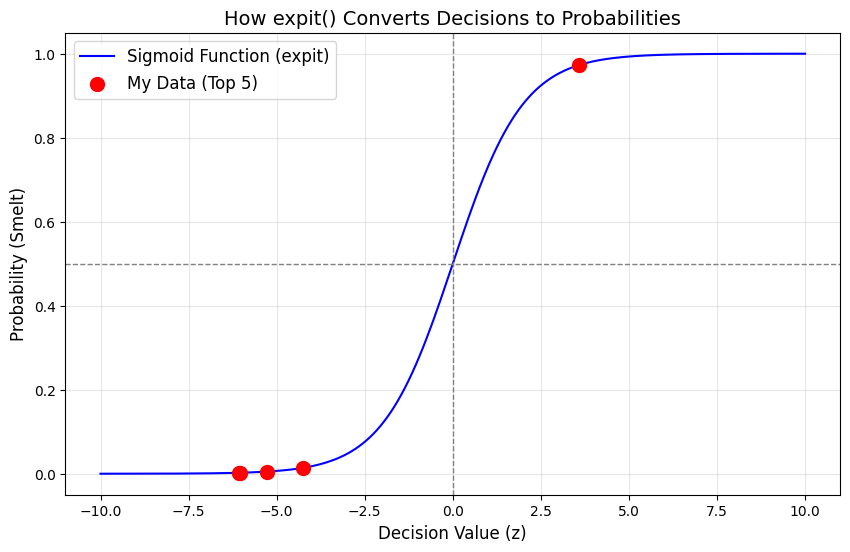

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import expit

# 1. 기존에 구한 decision_function 값 (5개 샘플의 z값)
decisions = lr.decision_function(train_bream_smelt[:5])
probabilities = expit(decisions)

# 2. 예쁜 시그모이드 곡선을 그리기 위한 가상 데이터 생성 (-10부터 10까지)
x = np.linspace(-10, 10, 200)
y = expit(x)

# 3. 그래프 그리기
plt.figure(figsize=(10, 6))

# 시그모이드 기본 곡선 (파란 선)
plt.plot(x, y, color='blue', label='Sigmoid Function (expit)')

# 실제 데이터 5개의 위치 (빨간 점)
plt.scatter(decisions, probabilities, color='red', s=100, zorder=5, label='My Data (Top 5)')

# 그래프를 쉽게 보기 위한 가이드선 (y=0.5 확률 기준선, x=0 결정 기준선)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# 그래프 꾸미기
plt.title('How expit() Converts Decisions to Probabilities', fontsize=14)
plt.xlabel('Decision Value (z)', fontsize=12)
plt.ylabel('Probability (Smelt)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

plt.show()

# 다중 분류
- softmax 함수
    - e(자연 로그의 밑) 지수 함수를 함수를 적용
    - 정규화 -> 모든 확률의 합은 100%가 되게끔. 하지만 가장 큰 점수를 극대화 시키는 함수.

In [12]:
# 전체 7종 분류
lr = LogisticRegression(C = 20, max_iter = 1000)
lr.fit(train_scaled, train_target)
# C(규제의 역수) 값은 클수록 규제가 약하고 자유도가 높음
# max_iter는 한번에 결정경계


print(lr.classes_)
# ['Bream' 'Parkki', 'Perch', 'Pike'
# 'Roach' 'Smelt' 'Whitefish']

proba = lr.predict_proba(test_scaled[:3])
print(proba.round(3))

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]]


In [27]:
decision = lr.decision_function(test_scaled[:5])

In [ ]:
from scipy.special import softmax
proba_from_softmax = softmax(decision, axis=1)
proba_from_softmax.round(3) #결과가 로지스틱 회귀의 결과와 같다
#다항 분류의 경우 softma를 사용한다

array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

In [29]:
# 평가
lr.score(test_scaled, test_target) # 정확도 92.5%

0.925

In [32]:
from sklearn.metrics import confusion_matrix

y_true = [1,0,1,1,0,1,0,0]
y_pred = [1,0,0,1,0,1,1,0]

confusion_matrix(y_true, y_pred)

array([[3, 1],
       [1, 3]])

In [23]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # 추가
from sklearn.metrics import roc_auc_score           # 추가

titanic = sns.load_dataset('titanic')

# [기존 코드] 기본 전처리
titanic_clean = titanic[['survived','pclass','sex','age','sibsp','parch','fare']].dropna()

# [기존 코드] 인코딩
titanic_clean = pd.get_dummies(titanic_clean, columns=['sex'], drop_first=True)

X = titanic_clean.drop('survived', axis=1).values
y = titanic_clean['survived'].values

# [기존 코드] 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y)

ss = StandardScaler()
X_train_s = ss.fit_transform(X_train)
X_test_s  = ss.transform(X_test)

print("생존:", y.sum(), "사망:", len(y) - y.sum())
print("생존 비율:", y.mean().round(3))

# -----------------------------------------------------------------
# 💡 여기서부터 새로 추가해서 실행하시면 됩니다!
# -----------------------------------------------------------------

# 1. 타이타닉 전용 로지스틱 회귀 모델 새로 만들기 (lr_titanic)
lr_titanic = LogisticRegression()

# 2. 타이타닉 훈련 데이터(특성 6개)로 새로 학습시키기
lr_titanic.fit(X_train_s, y_train)

# 3. 타이타닉 테스트 데이터로 생존 확률(1일 확률) 예측하기
y_score = lr_titanic.predict_proba(X_test_s)[:, 1]
print("\n예측 확률 (앞의 3개):", y_score[:3])

# 4. ROC AUC 점수 계산 및 출력
auc = roc_auc_score(y_test, y_score)
print("타이타닉 ROC AUC 점수:", round(auc, 4))

생존: 290 사망: 424
생존 비율: 0.406

예측 확률 (앞의 3개): [0.08897927 0.20280058 0.09118474]
타이타닉 ROC AUC 점수: 0.8635


In [15]:
# 인코딩
x = titanic_clean.drop('survived', axis=1)

In [17]:
# ROC AUC 점수
from sklearn.metrics import roc_auc_score

# lr 대신 lr_titanic 객체명을 사용해야 합니다!
y_score = lr_titanic.predict_proba(X_test_s)[:, 1]

print("예측 확률 (앞의 3개):", y_score[:3])

# ROC AUC 점수 계산 및 출력
auc_score = roc_auc_score(y_test, y_score)
print("타이타닉 ROC AUC 점수:", round(auc_score, 4))

예측 확률 (앞의 3개): [0.08897927 0.20280058 0.09118474]
타이타닉 ROC AUC 점수: 0.8635


In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, confusion_matrix

# 1. 데이터 로드 및 label 방향 확인
data = load_breast_cancer()
print("원래 target_names:", data.target_names) 

# 2. label 뒤집기 (1을 악성으로 변경)
X = data.data
y = 1 - data.target  

# 3. stratify=y 적용하여 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 4. 모델 학습 및 예측 확률 추출
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]  

# 5. 기본 임계값(0.5) 결과
print("\n[기본 임계값 0.5 결과]")
y_pred_default = (y_prob >= 0.5).astype(int)
print(confusion_matrix(y_test, y_pred_default))

# 6. 임계값 조정 (0.3) -> FN 최소화 전략
print("\n[조정된 임계값 0.3 결과]")
y_pred_custom = (y_prob >= 0.3).astype(int)
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

원래 target_names: ['malignant' 'benign']

[기본 임계값 0.5 결과]
[[106   1]
 [  9  55]]

[조정된 임계값 0.3 결과]
[[105   2]
 [  5  59]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       107
           1       0.97      0.92      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



## 1. 로지스틱 회귀와 확률 (시그모이드 & 소프트맥스)
> **"합격 점수를 '합격 확률'로 바꿔주는 마법의 필터"**

로지스틱 회귀(Logistic Regression) 모델은 데이터를 가지고 열심히 계산해서 내부적으로 어떤 '점수'를 냅니다. 하지만 점수가 `150점`, `-30점`처럼 들쭉날쭉 나오면 이게 얼마나 확실하다는 건지 알기 어렵죠. 그래서 이 점수를 **0%에서 100% 사이의 예쁜 확률**로 바꿔주는 마법의 필터를 통과시킵니다.

* **시그모이드(Sigmoid) 함수 `[이진 분류]`**
  * **비유**: *"오늘 비가 올까? 안 올까?"* 처럼 **답이 딱 두 개(예/아니오)**일 때 씁니다.
  * 어떤 점수가 들어오든 무조건 `0(0%)`과 `1(100%)` 사이로 꾹 눌러서 짜줍니다. *"오늘 비 올 확률은 80%야"*라고 말해주는 필터입니다.
* **소프트맥스(Softmax) 함수 `[다중 분류]`**
  * **비유**: *"이 동물은 개일까, 고양이일까, 토끼일까?"* 처럼 **고를 수 있는 정답 후보가 여러 개**일 때 씁니다.
  * 각 후보의 점수를 다 합쳐서 총합이 딱 `100%(1.0)`가 되도록 비율을 나눠 가집니다. 예를 들어 *"개 70%, 고양이 20%, 토끼 10%"*처럼 사이좋게 확률을 나눠 갖게 만드는 필터입니다.

---

## 2. 오차 행렬 (Confusion Matrix)과 오류들
> **"정답과 오답을 기록하는 2x2 바둑판 점수표"**

모델이 예측한 것과 실제 정답을 비교할 때, 헷갈리지 않게 바둑판 모양의 표로 정리한 것이 오차 행렬입니다. **코로나 검사 키트**를 예로 들어볼게요.

| 구분 | 실제 코로나 (Positive) | 실제 건강함 (Negative) |
| :--- | :--- | :--- |
| **의사의 예측: "코로나 맞네!"** | **TP** (진짜 양성) <br> 예측 성공! | **FP** (가짜 양성) <br> **1형 오류 (Type I)** |
| **의사의 예측: "건강하네요!"** | **FN** (가짜 음성) <br> **2형 오류 (Type II)** | **TN** (진짜 음성) <br> 예측 성공! |

* **TP (True Positive, 진짜 양성)**: 의사가 "너 코로나 맞네" 했는데, 실제로도 코로나인 경우.
* **TN (True Negative, 진짜 음성)**: 의사가 "너 건강하네" 했는데, 실제로도 건강한 경우.
* **FP (False Positive, 가짜 양성) `[1형 오류]`**: 의사가 "너 코로나야!" 했는데, 알고 보니 그냥 감기였던 경우. 멀쩡한 사람한테 난리를 친 **'형사의 오판(죄 없는 사람을 죄인 취급)'** 같은 오류입니다.
* **FN (False Negative, 가짜 음성) `[2형 오류]`**: 의사가 "너 건강하네, 집에 가" 했는데, 실제로 코로나에 걸려있던 경우. 진짜 환자를 놓쳐버린 **'도둑을 놓친 경찰'** 같은 오류입니다. 병을 놓치면 전염되거나 큰일이 날 수 있으니 보통 **2형 오류가 훨씬 더 위험**합니다.

---

## 3. 불균형 데이터와 평가 지표들
> **"전교생 중 딱 한 명만 빌런(악당)인 학교 이야기"**

어떤 학교에 전교생이 1,000명인데, 그중 진짜 악당이 딱 1명 있습니다. 그런데 어떤 게으른 탐정이 나타나서 **"난 아무 조사도 안 하고 그냥 1,000명 전부 다 착한 학생이라고 찍을래!"**라고 했습니다.

* **왜 정확도(Accuracy)가 무의미할까요?**
  * 이 게으른 탐정의 정확도는 무려 **99.9%** (1,000명 중 999명 맞춤)입니다. 엄청나 보이죠? 하지만 정작 중요한 '악당 1명'은 전혀 못 잡았습니다. 이처럼 데이터가 한쪽으로 엄청나게 쏠려있을 때(불균형 데이터)는 단순히 몇 개 맞췄는지 보는 '정확도'는 아무 쓸모가 없습니다.



그래서 아래와 같은 **보완 지표**들을 사용합니다.
* **정밀도 (Precision)**: 탐정이 *"내가 악당이라고 지목한 애들 중에서 진짜 악당이 몇 명이나 있어?"*를 보는 지표입니다. (억울하게 의심받는 사람이 없어야 할 때 중요!)
* **재현율 (Recall)**: *"학교에 숨어있는 진짜 악당들 중에서, 탐정이 몇 명이나 놓치지 않고 잡아냈어?"*를 보는 지표입니다. (악당을 절대 놓치면 안 되는 보안/의학에서 중요!)
* **F1-스코어 (F1-Score)**: 정밀도와 재현율은 서로 밀당을 하는 관계입니다. 그래서 두 점수를 골고루 섞어 만든 **'종합 짬짜면 점수'**입니다. 데이터 쏠림이 심할 때 이 점수가 높아야 진짜 우승자입니다.
* **ROC-AUC**: 탐정이 악당을 찾아내는 **'순수 구별 스킬 점수'**입니다. 탐정이 기준을 깐깐하게 잡든, 헐렁하게 잡든 상관없이 착한 학생과 악당을 얼마나 확실하게 가려내는지를 `0`에서 `1` 사이의 점수로 나타냅니다. `1`에 가까울수록 구별 천재입니다.

---

## 4. 모델 상태 진단 (High Bias / High Variance)
> **"시험 공부를 하는 세 가지 유형의 학생"**

컴퓨터가 공부한 문제집 점수(**Train Score**)와 처음 보는 실전 시험 점수(**Test Score**)의 조합을 보면 컴퓨터의 상태를 진단할 수 있습니다.

```text
[공부 점수 바닥] + [시험 점수 바닥] -> 과소적합 (High Bias)
[공부 점수 백점] + [시험 점수 반토막] -> 과적합 (High Variance)
[공부 점수 우수] + [시험 점수 우수]   -> 적절한 피팅 (Good)

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. 불균형 데이터셋 준비 (정상 900개, 스팸 100개)
np.random.seed(42)
normal = np.random.normal(loc=2, scale=1, size=(900, 2))
spam = np.random.normal(loc=6, scale=1, size=(100, 2))

X = np.vstack([normal, spam])
y = np.array([0] * 900 + [1] * 100) # 0:정상, 1:스팸

# 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. 모델 생성 (시그모이드 확률 출력 및 조기 종료 설정)
model = SGDClassifier(loss='log_loss', max_iter=1000, early_stopping=True, 
                      validation_fraction=0.1, n_iter_no_change=5, tol=0.001, random_state=42)
model.fit(X_train_scaled, y_train)

# 3. 결과 및 지표 출력
print("=== 1. 예측 확률 (앞 3개) ===")
print(model.predict_proba(X_test_scaled[:3])) 

print("\n=== 2. 오차 행렬 (TN, FP / FN, TP) ===")
y_pred = model.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred))

print("\n=== 3. 분류 리포트 (정확도, 정밀도, 재현율, F1) ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Spam']))

print("=== 4. ROC-AUC 점수 ===")
y_prob_spam = model.predict_proba(X_test_scaled)[:, 1]
print(f"{roc_auc_score(y_test, y_prob_spam):.4f}")

print("\n=== 5. 모델 상태 진단 ===")
print(f"Train Score: {model.score(X_train_scaled, y_train):.4f}")
print(f"Test Score : {model.score(X_test_scaled, y_test):.4f}")

=== 1. 예측 확률 (앞 3개) ===
[[1.00000000e+00 3.54538753e-10]
 [1.00000000e+00 6.64634309e-14]
 [1.00000000e+00 4.24626987e-12]]

=== 2. 오차 행렬 (TN, FP / FN, TP) ===
[[179   0]
 [  0  21]]

=== 3. 분류 리포트 (정확도, 정밀도, 재현율, F1) ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       179
        Spam       1.00      1.00      1.00        21

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

=== 4. ROC-AUC 점수 ===
1.0000

=== 5. 모델 상태 진단 ===
Train Score: 1.0000
Test Score : 1.0000
